# Podcast Ad Detection Classifier

CS 6480 Deep Learning — Course Project

**Goal:** Detect advertisement segments in podcast transcripts using three approaches:
1. Keyword/regex baseline
2. TF-IDF + Logistic Regression
3. Fine-tuned DistilBERT

**Training data:** 2,000 LLM-generated synthetic segments (balanced 50/50) + real segments from 8 YouTube videos (mixed in to close the synthetic-to-real domain gap)

**Test data:** Real segments from 18 held-out YouTube videos labeled via SponsorBlock (split by video to prevent leakage)

## 1. Setup & Imports

In [22]:
# Colab: install dependencies & upload data
!pip install -q transformers[torch] accelerate scikit-learn

import os
if not os.path.exists("data"):
    os.makedirs("data", exist_ok=True)
    from google.colab import files
    print("Upload synthetic_train.jsonl")
    uploaded = files.upload()
    for name, content in uploaded.items():
        with open(f"data/{name}", "wb") as f:
            f.write(content)
    print("Upload real_test.jsonl")
    uploaded = files.upload()
    for name, content in uploaded.items():
        with open(f"data/{name}", "wb") as f:
            f.write(content)


In [23]:
import json
import re
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
)

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch 2.10.0+cu128
Device: cuda


## 2. Data Loading & Exploration

In [24]:
DATA_DIR = Path("data")

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

synthetic = load_jsonl(DATA_DIR / "synthetic_train.jsonl")
all_real = load_jsonl(DATA_DIR / "real_test.jsonl")

syn_texts = [s["text"] for s in synthetic]
syn_labels = [s["label"] for s in synthetic]

# --- Split real data by video: 8 videos for training, rest for testing ---
all_videos = sorted(set(r["video_id"] for r in all_real))
random.seed(42)
random.shuffle(all_videos)

N_TRAIN_VIDEOS = 8
train_videos = set(all_videos[:N_TRAIN_VIDEOS])
test_videos = set(all_videos[N_TRAIN_VIDEOS:])

real_train_data = [r for r in all_real if r["video_id"] in train_videos]
real_test_data = [r for r in all_real if r["video_id"] in test_videos]

real_train_texts = [r["text"] for r in real_train_data]
real_train_labels = [r["label"] for r in real_train_data]
real_texts = [r["text"] for r in real_test_data]
real_labels = [r["label"] for r in real_test_data]

print("=== Synthetic Training Data ===")
print(f"  Total: {len(synthetic)}")
print(f"  Ads: {sum(syn_labels)}, Non-ads: {len(syn_labels) - sum(syn_labels)}")
syn_cats = Counter(s["category"] for s in synthetic)
print(f"  Categories: {len(syn_cats)}")
for cat, count in syn_cats.most_common():
    print(f"    {cat}: {count}")

print(f"\n=== Real Data — Train Videos ({len(train_videos)} videos) ===")
print(f"  Total: {len(real_train_data)}")
print(f"  Ads: {sum(real_train_labels)}, Non-ads: {len(real_train_labels) - sum(real_train_labels)}")
for vid in sorted(train_videos):
    segs = [r for r in real_train_data if r["video_id"] == vid]
    ads = sum(1 for r in segs if r["label"] == 1)
    print(f"    {vid}: {len(segs)} segments ({ads} ads)")

print(f"\n=== Real Data — Test Videos ({len(test_videos)} videos) ===")
print(f"  Total: {len(real_test_data)}")
print(f"  Ads: {sum(real_labels)}, Non-ads: {len(real_labels) - sum(real_labels)}")
for vid in sorted(test_videos):
    segs = [r for r in real_test_data if r["video_id"] == vid]
    ads = sum(1 for r in segs if r["label"] == 1)
    print(f"    {vid}: {len(segs)} segments ({ads} ads)")

=== Synthetic Training Data ===
  Total: 2000
  Ads: 1000, Non-ads: 1000
  Categories: 15
    host_read_ad: 300
    promo_code_ad: 200
    interview: 200
    midroll_transition: 150
    storytelling: 150
    monologue: 150
    banter: 100
    news_recap: 100
    preroll_ad: 100
    technical_discussion: 100
    subtle_ad: 100
    intro_outro: 100
    product_testimonial_ad: 100
    product_mention_organic: 100
    cross_promo: 50

=== Real Data — Train Videos (8 videos) ===
  Total: 613
  Ads: 26, Non-ads: 587
    9szhjhO9epA: 42 segments (4 ads)
    DqAKQwagCDg: 28 segments (4 ads)
    HBluLfX2F_k: 91 segments (3 ads)
    KGVpKPNUdzA: 21 segments (1 ads)
    NIk_0AW5hFU: 82 segments (3 ads)
    XKSjCOKDtpk: 69 segments (5 ads)
    ZxobPzkE4r0: 27 segments (4 ads)
    vif8NQcjVf0: 253 segments (2 ads)

=== Real Data — Test Videos (18 videos) ===
  Total: 2020
  Ads: 61, Non-ads: 1959
    -YNk9_e4pg4: 41 segments (5 ads)
    -q2n5DkDoMQ: 46 segments (4 ads)
    1SJiTwbSI58: 287 segments

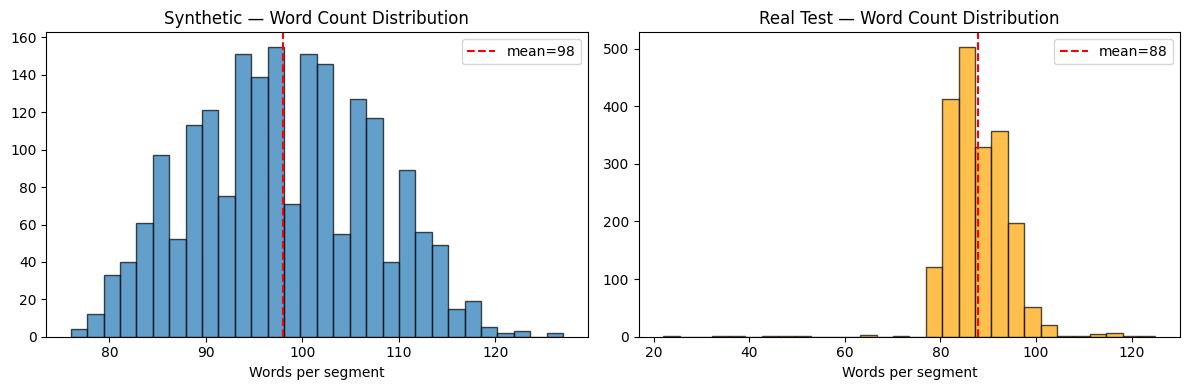

In [25]:
# Text length distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

syn_wc = [len(t.split()) for t in syn_texts]
real_wc = [len(t.split()) for t in real_texts]

axes[0].hist(syn_wc, bins=30, alpha=0.7, edgecolor="black")
axes[0].set_title("Synthetic — Word Count Distribution")
axes[0].set_xlabel("Words per segment")
axes[0].axvline(np.mean(syn_wc), color="red", linestyle="--", label=f"mean={np.mean(syn_wc):.0f}")
axes[0].legend()

axes[1].hist(real_wc, bins=30, alpha=0.7, color="orange", edgecolor="black")
axes[1].set_title("Real Test — Word Count Distribution")
axes[1].set_xlabel("Words per segment")
axes[1].axvline(np.mean(real_wc), color="red", linestyle="--", label=f"mean={np.mean(real_wc):.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
# Filler word prevalence in synthetic data — a potential domain gap issue
fillers = ["uh", "um", "like", "you know", "honestly", "actually", "basically"]
all_real_texts = [r["text"] for r in all_real]

print("Filler word prevalence in synthetic data:")
for filler in fillers:
    count = sum(1 for t in syn_texts if filler in t.lower())
    print(f"  '{filler}': {count}/{len(syn_texts)} ({count/len(syn_texts)*100:.1f}%)")

print("\nFiller word prevalence in real data:")
for filler in fillers:
    count = sum(1 for t in all_real_texts if filler in t.lower())
    print(f"  '{filler}': {count}/{len(all_real_texts)} ({count/len(all_real_texts)*100:.1f}%)")

Filler word prevalence in synthetic data:
  'uh': 680/2000 (34.0%)
  'um': 777/2000 (38.9%)
  'like': 1035/2000 (51.7%)
  'you know': 646/2000 (32.3%)
  'honestly': 30/2000 (1.5%)
  'actually': 118/2000 (5.9%)
  'basically': 0/2000 (0.0%)

Filler word prevalence in real data:
  'uh': 29/2633 (1.1%)
  'um': 665/2633 (25.3%)
  'like': 1304/2633 (49.5%)
  'you know': 490/2633 (18.6%)
  'honestly': 7/2633 (0.3%)
  'actually': 349/2633 (13.3%)
  'basically': 106/2633 (4.0%)


In [27]:
# Example segments
print("=== Example Synthetic Ad ===")
ad_ex = next(s for s in synthetic if s["label"] == 1)
print(f"  Category: {ad_ex['category']}")
print(f"  Text: {ad_ex['text'][:300]}...")

print("\n=== Example Synthetic Non-Ad ===")
nonad_ex = next(s for s in synthetic if s["label"] == 0)
print(f"  Category: {nonad_ex['category']}")
print(f"  Text: {nonad_ex['text'][:300]}...")

print("\n=== Example Real Ad ===")
real_ad = next(r for r in real_test if r["label"] == 1)
print(f"  Video: {real_ad['video_id']}")
print(f"  Text: {real_ad['text'][:300]}...")

print("\n=== Example Real Non-Ad ===")
real_nonad = next(r for r in real_test if r["label"] == 0)
print(f"  Video: {real_nonad['video_id']}")
print(f"  Text: {real_nonad['text'][:300]}...")

=== Example Synthetic Ad ===
  Category: host_read_ad
  Text: This episode is brought to you by mindMap Notes Look I've been in this space for a while and MindMap Notes is one of the few products I stand uh behind. It has made um a real difference in my daily routine. you know And that is not something you hear people talk about enough. You can try it at mindm...

=== Example Synthetic Non-Ad ===
  Category: banter
  Text: Can we talk about the fact that I am still writing the wrong year on things And that is coming from someone who has been doing this for a while. Like where does the time go. The more I think about it the right more um convinced I am. I do not know if that makes sense but it is right how I think abou...

=== Example Real Ad ===
  Video: vif8NQcjVf0
  Text: And in the meantime, my, my favorite answer is eliminate waste. You know, we've, we've got all that idle power. I want to evacuate it as fast as possible. Yeah, there, there's a lot of low hanging fruit here on eart

## 3. Preprocessing

The synthetic data generator injected filler words ("honestly", "actually", "like", etc.) into 50-70% of segments across both classes. This could create a spurious shortcut for the model.

We prepare **two versions** of the data — raw and cleaned — and train each model on both to empirically measure whether filler removal helps generalization to real data.

**Domain adaptation:** We mix real segments from 8 held-out training videos into the synthetic training set. This exposes the model to real Whisper transcription style, genuine ad phrasing, and natural speech patterns — helping bridge the synthetic-to-real gap. The remaining 18 videos are held out strictly for testing (no video appears in both splits).

In [28]:
FILLER_PATTERN = re.compile(
    r"\b(honestly|actually|basically|like|look|right|um|uh|well|you know)\b",
    re.IGNORECASE,
)

def clean_text(text):
    text = text.lower().strip()
    text = FILLER_PATTERN.sub("", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Prepare raw and cleaned versions of synthetic data
syn_texts_raw = syn_texts
syn_texts_clean = [clean_text(t) for t in syn_texts]
real_texts_raw = real_texts
real_texts_clean = [clean_text(t) for t in real_texts]

# Clean versions of real train data
real_train_texts_clean = [clean_text(t) for t in real_train_texts]

# Train/val split on synthetic data — same indices for both versions
train_idx, val_idx = train_test_split(
    range(len(syn_texts)), test_size=0.2, stratify=syn_labels, random_state=42
)

# Synthetic train + real train mixed together
train_texts_raw = [syn_texts_raw[i] for i in train_idx] + real_train_texts
train_texts_clean = [syn_texts_clean[i] for i in train_idx] + real_train_texts_clean
train_labels = [syn_labels[i] for i in train_idx] + real_train_labels

# Validation stays synthetic-only (measures how well model learns the task)
val_texts_raw = [syn_texts_raw[i] for i in val_idx]
val_texts_clean = [syn_texts_clean[i] for i in val_idx]
val_labels = [syn_labels[i] for i in val_idx]

syn_in_train = len(train_idx)
real_in_train = len(real_train_texts)
print(f"Train: {len(train_labels)} total ({syn_in_train} synthetic + {real_in_train} real)")
print(f"  Ads: {sum(train_labels)}, Non-ads: {len(train_labels) - sum(train_labels)}")
print(f"Val:   {len(val_labels)} (synthetic only, {sum(val_labels)} ads)")
print(f"Test:  {len(real_labels)} (real held-out, {sum(real_labels)} ads)")

# Show cleaning effect
print(f"\nExample cleaning:")
print(f"  Raw:     {syn_texts_raw[0][:150]}...")
print(f"  Cleaned: {syn_texts_clean[0][:150]}...")

Train: 2213 total (1600 synthetic + 613 real)
  Ads: 826, Non-ads: 1387
Val:   400 (synthetic only, 200 ads)
Test:  2020 (real held-out, 61 ads)

Example cleaning:
  Raw:     This episode is brought to you by mindMap Notes Look I've been in this space for a while and MindMap Notes is one of the few products I stand uh behin...
  Cleaned: this episode is brought to you by mindmap notes i've been in this space for a while and mindmap notes is one of the few products i stand behind. it ha...


In [29]:
# Shared evaluation helper
all_results = []

def evaluate(y_true, y_pred, model_name, dataset_name, verbose=True):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    result = {
        "Model": model_name, "Dataset": dataset_name,
        "Accuracy": acc, "Precision": p, "Recall": r, "F1": f1,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }
    all_results.append(result)
    if verbose:
        print(f"\n{model_name} on {dataset_name}:")
        print(f"  Accuracy={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}")
        print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    return result

## 4. Model 1 — Keyword/Regex Baseline\n\nA simple pattern matcher that predicts "ad" if the text contains any common ad-related phrases. This provides an interpretable lower bound.

In [30]:
AD_PATTERNS = [
    re.compile(p, re.IGNORECASE) for p in [
        r"sponsor(ed|s)?\s+by",
        r"promo\s*code",
        r"use\s+code\s+\w+",
        r"brought\s+to\s+you\s+by",
        r"percent\s+off",
        r"\d+%\s+off",
        r"free\s+trial",
        r"\.com\s*(slash|\/)\s*\w+",
        r"thank\s+(you\s+)?to\s+(our\s+)?sponsors?",
        r"link\s+in\s+the\s+description",
        r"discount\s+(code|on)",
        r"check\s+(them\s+)?out\s+at\s+\w+",
        r"sign\s+up\s+(at|with)",
        r"go\s+to\s+\w+\.\w+",
        r"special\s+offer",
        r"limited\s+time",
        r"(first|next)\s+\d+\s+(order|month|purchase)",
    ]
]

def keyword_predict(text):
    for pattern in AD_PATTERNS:
        if pattern.search(text):
            return 1
    return 0

# Evaluate on validation and real test (raw text — regex is content-based)
kw_val_preds = [keyword_predict(t) for t in val_texts_raw]
kw_real_preds = [keyword_predict(t) for t in real_texts_raw]

evaluate(val_labels, kw_val_preds, "Keyword", "Validation")
evaluate(real_labels, kw_real_preds, "Keyword", "Real Test")


Keyword on Validation:
  Accuracy=0.880  Precision=0.994  Recall=0.765  F1=0.864
  TP=153  FP=1  FN=47  TN=199

Keyword on Real Test:
  Accuracy=0.978  Precision=0.905  Recall=0.311  F1=0.463
  TP=19  FP=2  FN=42  TN=1957


{'Model': 'Keyword',
 'Dataset': 'Real Test',
 'Accuracy': np.float64(0.9782178217821782),
 'Precision': 0.9047619047619048,
 'Recall': 0.3114754098360656,
 'F1': 0.4634146341463415,
 'TP': np.int64(19),
 'FP': np.int64(2),
 'FN': np.int64(42),
 'TN': np.int64(1957)}

## 5. Model 2 — TF-IDF + Logistic Regression\n\nA statistical baseline using TF-IDF features with bigrams. Trained on both raw and cleaned text to measure the effect of filler removal.

In [31]:
def train_tfidf_lr(train_texts, val_texts, real_texts, train_labels, val_labels, real_labels, label):
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
    X_train = tfidf.fit_transform(train_texts)
    X_val = tfidf.transform(val_texts)
    X_real = tfidf.transform(real_texts)

    lr = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0, random_state=42)
    lr.fit(X_train, train_labels)

    val_preds = lr.predict(X_val)
    real_preds = lr.predict(X_real)

    # Get probability scores for threshold tuning
    val_probs = lr.predict_proba(X_val)[:, 1]
    real_probs = lr.predict_proba(X_real)[:, 1]

    evaluate(val_labels, val_preds.tolist(), f"TF-IDF+LR ({label})", "Validation")
    evaluate(real_labels, real_preds.tolist(), f"TF-IDF+LR ({label})", "Real Test")

    return tfidf, lr, real_preds, val_probs, real_probs

# Train on raw text
print("=" * 50)
print("TF-IDF + LR on RAW text")
print("=" * 50)
tfidf_raw, lr_raw, lr_raw_real_preds, val_probs_raw, real_probs_raw = train_tfidf_lr(
    train_texts_raw, val_texts_raw, real_texts_raw,
    train_labels, val_labels, real_labels, "raw"
)

# Train on cleaned text
print("\n" + "=" * 50)
print("TF-IDF + LR on CLEANED text")
print("=" * 50)
tfidf_clean, lr_clean, lr_clean_real_preds, val_probs_clean, real_probs_clean = train_tfidf_lr(
    train_texts_clean, val_texts_clean, real_texts_clean,
    train_labels, val_labels, real_labels, "clean"
)

TF-IDF + LR on RAW text

TF-IDF+LR (raw) on Validation:
  Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
  TP=200  FP=0  FN=0  TN=200

TF-IDF+LR (raw) on Real Test:
  Accuracy=0.974  Precision=1.000  Recall=0.131  F1=0.232
  TP=8  FP=0  FN=53  TN=1959

TF-IDF + LR on CLEANED text

TF-IDF+LR (clean) on Validation:
  Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
  TP=200  FP=0  FN=0  TN=200

TF-IDF+LR (clean) on Real Test:
  Accuracy=0.974  Precision=1.000  Recall=0.131  F1=0.232
  TP=8  FP=0  FN=53  TN=1959


In [32]:
# Top features for each class (cleaned model)
feature_names = tfidf_clean.get_feature_names_out()
coefs = lr_clean.coef_[0]
top_ad = np.argsort(coefs)[-20:][::-1]
top_nonad = np.argsort(coefs)[:20]

print("Top 20 features — AD class (cleaned model):")
for i in top_ad:
    print(f"  {feature_names[i]:30s} coef={coefs[i]:.3f}")

print("\nTop 20 features — NON-AD class (cleaned model):")
for i in top_nonad:
    print(f"  {feature_names[i]:30s} coef={coefs[i]:.3f}")

Top 20 features — AD class (cleaned model):
  code                           coef=3.147
  com                            coef=2.910
  co                             coef=2.368
  use                            coef=2.108
  quick                          coef=1.853
  link                           coef=1.821
  slash                          coef=1.820
  use code                       coef=1.749
  check                          coef=1.714
  go to                          coef=1.693
  link in                        coef=1.594
  out                            coef=1.541
  them                           coef=1.485
  your                           coef=1.428
  sponsor                        coef=1.420
  percent                        coef=1.363
  and use                        coef=1.329
  check them                     coef=1.278
  go                             coef=1.273
  deal                           coef=1.244

Top 20 features — NON-AD class (cleaned model):
  the                      

## 5b. Threshold Tuning & PR Curves

The default classification threshold of 0.5 assumes equal cost for false positives and false negatives. Since we prioritize **recall** (catching ads), we:

1. **Sweep thresholds** from 0.01 to 0.99 on the validation set
2. **Optimize F-beta (β=2)** which weights recall 4× more than precision
3. **Plot Precision-Recall curves** to visualize the tradeoff at every threshold
4. **Re-evaluate on real test** using the tuned threshold

This also addresses the class imbalance gap: the model is trained on balanced 50/50 data but tested on ~1% ad data. Threshold tuning corrects the decision boundary for the real distribution.

In [33]:
from sklearn.metrics import fbeta_score, precision_recall_curve

def sweep_threshold(y_true, probs, model_name, beta=2):
    """Sweep thresholds and find optimal for F-beta score."""
    thresholds = np.arange(0.01, 1.0, 0.01)
    f_scores = []
    precisions = []
    recalls = []
    for thresh in thresholds:
        preds = (probs >= thresh).astype(int)
        f = fbeta_score(y_true, preds, beta=beta, zero_division=0)
        p, r, _, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
        f_scores.append(f)
        precisions.append(p)
        recalls.append(r)

    best_idx = np.argmax(f_scores)
    best_thresh = thresholds[best_idx]
    best_f = f_scores[best_idx]

    print(f"{model_name}:")
    print(f"  Default (0.50) — F{beta}={fbeta_score(y_true, (probs >= 0.5).astype(int), beta=beta, zero_division=0):.3f}")
    print(f"  Optimal ({best_thresh:.2f}) — F{beta}={best_f:.3f}")
    print(f"  At optimal: Precision={precisions[best_idx]:.3f}, Recall={recalls[best_idx]:.3f}")

    return best_thresh, thresholds, f_scores, precisions, recalls

# Sweep on validation set
print("=== Threshold Sweep on Validation Set (F2 optimization) ===\n")
thresh_raw, ts_raw, fs_raw, ps_raw, rs_raw = sweep_threshold(
    val_labels, val_probs_raw, "TF-IDF+LR (raw)"
)
thresh_clean, ts_clean, fs_clean, ps_clean, rs_clean = sweep_threshold(
    val_labels, val_probs_clean, "TF-IDF+LR (clean)"
)

=== Threshold Sweep on Validation Set (F2 optimization) ===

TF-IDF+LR (raw):
  Default (0.50) — F2=1.000
  Optimal (0.43) — F2=1.000
  At optimal: Precision=1.000, Recall=1.000
TF-IDF+LR (clean):
  Default (0.50) — F2=1.000
  Optimal (0.40) — F2=1.000
  At optimal: Precision=1.000, Recall=1.000


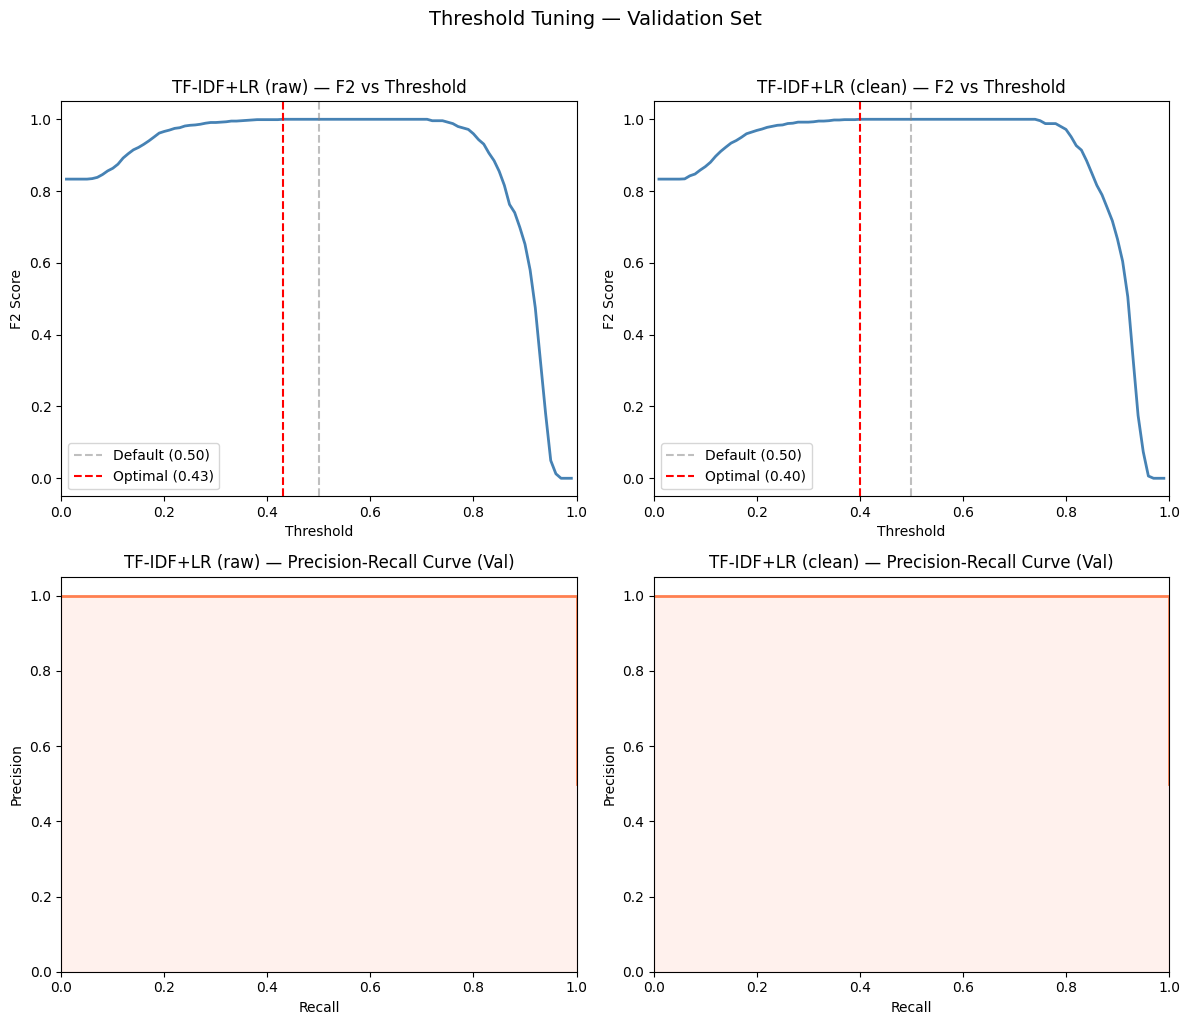

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top row: F2 score vs threshold
for ax, ts, fs, thresh, label in [
    (axes[0, 0], ts_raw, fs_raw, thresh_raw, "TF-IDF+LR (raw)"),
    (axes[0, 1], ts_clean, fs_clean, thresh_clean, "TF-IDF+LR (clean)"),
]:
    ax.plot(ts, fs, color="steelblue", linewidth=2)
    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default (0.50)")
    ax.axvline(thresh, color="red", linestyle="--", label=f"Optimal ({thresh:.2f})")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("F2 Score")
    ax.set_title(f"{label} — F2 vs Threshold")
    ax.legend()
    ax.set_xlim(0, 1)

# Bottom row: Precision-Recall curves
for ax, probs, labels, label in [
    (axes[1, 0], val_probs_raw, val_labels, "TF-IDF+LR (raw)"),
    (axes[1, 1], val_probs_clean, val_labels, "TF-IDF+LR (clean)"),
]:
    precision, recall, thresholds = precision_recall_curve(labels, probs)
    ax.plot(recall, precision, color="coral", linewidth=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{label} — Precision-Recall Curve (Val)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.fill_between(recall, precision, alpha=0.1, color="coral")

plt.suptitle("Threshold Tuning — Validation Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [35]:
# Re-evaluate on real test using tuned thresholds
print("=== Real Test with Tuned Thresholds ===\n")

# Raw model with tuned threshold
tuned_raw_preds = (real_probs_raw >= thresh_raw).astype(int).tolist()
evaluate(real_labels, tuned_raw_preds, f"TF-IDF+LR tuned@{thresh_raw:.2f} (raw)", "Real Test")

# Clean model with tuned threshold
tuned_clean_preds = (real_probs_clean >= thresh_clean).astype(int).tolist()
evaluate(real_labels, tuned_clean_preds, f"TF-IDF+LR tuned@{thresh_clean:.2f} (clean)", "Real Test")

# Compare default vs tuned
print("\n" + "=" * 60)
print("Default (0.50) vs Tuned Threshold — Real Test Comparison")
print("=" * 60)
for label, default_name, tuned_name in [
    ("raw", "TF-IDF+LR (raw)", f"TF-IDF+LR tuned@{thresh_raw:.2f} (raw)"),
    ("clean", "TF-IDF+LR (clean)", f"TF-IDF+LR tuned@{thresh_clean:.2f} (clean)"),
]:
    default = next(r for r in all_results if r["Model"] == default_name and r["Dataset"] == "Real Test")
    tuned = next(r for r in all_results if r["Model"] == tuned_name and r["Dataset"] == "Real Test")
    print(f"\n{label.upper()}:")
    print(f"  Default:  P={default['Precision']:.3f}  R={default['Recall']:.3f}  F1={default['F1']:.3f}  TP={default['TP']}  FP={default['FP']}")
    print(f"  Tuned:    P={tuned['Precision']:.3f}  R={tuned['Recall']:.3f}  F1={tuned['F1']:.3f}  TP={tuned['TP']}  FP={tuned['FP']}")

=== Real Test with Tuned Thresholds ===


TF-IDF+LR tuned@0.43 (raw) on Real Test:
  Accuracy=0.977  Precision=1.000  Recall=0.246  F1=0.395
  TP=15  FP=0  FN=46  TN=1959

TF-IDF+LR tuned@0.40 (clean) on Real Test:
  Accuracy=0.978  Precision=1.000  Recall=0.262  F1=0.416
  TP=16  FP=0  FN=45  TN=1959

Default (0.50) vs Tuned Threshold — Real Test Comparison

RAW:
  Default:  P=1.000  R=0.131  F1=0.232  TP=8  FP=0
  Tuned:    P=1.000  R=0.246  F1=0.395  TP=15  FP=0

CLEAN:
  Default:  P=1.000  R=0.131  F1=0.232  TP=8  FP=0
  Tuned:    P=1.000  R=0.262  F1=0.416  TP=16  FP=0


## 6. Model 3 — Fine-tuned DistilBERT (Primary Model)\n\nDistilBERT is a distilled version of BERT with 66M parameters (vs BERT's 110M), roughly 60% faster on CPU while retaining ~97% of BERT's performance.\n\nWe use `max_length=128` tokens — the real test data averages ~88 words which fits well. Some synthetic segments may be truncated, but ad signals tend to appear early in the segment.\n\nTrained on both raw and cleaned text for comparison.

In [36]:
class AdDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts, truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    acc = np.mean(preds == labels)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

In [37]:
MODEL_NAME = "distilbert-base-uncased"

def train_distilbert(train_texts, val_texts, real_texts, train_labels, val_labels, real_labels, label):
    """Fine-tune DistilBERT and return predictions on all datasets."""
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    train_dataset = AdDataset(train_texts, train_labels, tokenizer)
    val_dataset = AdDataset(val_texts, val_labels, tokenizer)
    real_dataset = AdDataset(real_texts, real_labels, tokenizer)

    training_args = TrainingArguments(
        output_dir=f"./results/distilbert_{label}",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
        use_cpu=DEVICE == "cpu",
        fp16=DEVICE == "cuda",
        report_to="none",
        seed=42,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    print(f"Training DistilBERT ({label})...")
    trainer.train()

    # Predictions
    val_preds = np.argmax(trainer.predict(val_dataset).predictions, axis=-1)
    real_preds = np.argmax(trainer.predict(real_dataset).predictions, axis=-1)

    evaluate(val_labels, val_preds.tolist(), f"DistilBERT ({label})", "Validation")
    evaluate(real_labels, real_preds.tolist(), f"DistilBERT ({label})", "Real Test")

    return trainer, real_preds

In [38]:
# Train on raw text
trainer_raw, bert_raw_real_preds = train_distilbert(
    train_texts_raw, val_texts_raw, real_texts_raw,
    train_labels, val_labels, real_labels, "raw"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training DistilBERT (raw)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.074651,0.008724,0.997500,1.000000,0.995000,0.997494
2,0.007757,0.000702,1.000000,1.000000,1.000000,1.000000
3,0.014396,0.000573,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT (raw) on Validation:
  Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
  TP=200  FP=0  FN=0  TN=200

DistilBERT (raw) on Real Test:
  Accuracy=0.979  Precision=0.694  Recall=0.557  F1=0.618
  TP=34  FP=15  FN=27  TN=1944


In [39]:
# Train on cleaned text
trainer_clean, bert_clean_real_preds = train_distilbert(
    train_texts_clean, val_texts_clean, real_texts_clean,
    train_labels, val_labels, real_labels, "clean"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training DistilBERT (clean)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.074611,0.002079,1.000000,1.000000,1.000000,1.000000
2,0.020978,0.001366,1.000000,1.000000,1.000000,1.000000
3,0.016414,0.000585,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT (clean) on Validation:
  Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
  TP=200  FP=0  FN=0  TN=200

DistilBERT (clean) on Real Test:
  Accuracy=0.978  Precision=0.793  Recall=0.377  F1=0.511
  TP=23  FP=6  FN=38  TN=1953


## 7. Comparison & Evaluation

With a heavily imbalanced real test set (~3% ads), accuracy is misleading — a model predicting all non-ad gets ~97%. We focus on **precision, recall, and F1** as the meaningful metrics.

Per the project proposal, recall is weighted more heavily: missing an ad is less disruptive than incorrectly flagging real content.

In [40]:
# Comparison table
print(f"{'Model':<25} {'Dataset':<12} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'TP':>4} {'FP':>4} {'FN':>4} {'TN':>5}")
print("-" * 95)
for r in all_results:
    print(f"{r['Model']:<25} {r['Dataset']:<12} {r['Accuracy']:>6.3f} {r['Precision']:>6.3f} {r['Recall']:>6.3f} {r['F1']:>6.3f} {r['TP']:>4} {r['FP']:>4} {r['FN']:>4} {r['TN']:>5}")

Model                     Dataset         Acc   Prec    Rec     F1   TP   FP   FN    TN
-----------------------------------------------------------------------------------------------
Keyword                   Validation    0.880  0.994  0.765  0.864  153    1   47   199
Keyword                   Real Test     0.978  0.905  0.311  0.463   19    2   42  1957
TF-IDF+LR (raw)           Validation    1.000  1.000  1.000  1.000  200    0    0   200
TF-IDF+LR (raw)           Real Test     0.974  1.000  0.131  0.232    8    0   53  1959
TF-IDF+LR (clean)         Validation    1.000  1.000  1.000  1.000  200    0    0   200
TF-IDF+LR (clean)         Real Test     0.974  1.000  0.131  0.232    8    0   53  1959
TF-IDF+LR tuned@0.43 (raw) Real Test     0.977  1.000  0.246  0.395   15    0   46  1959
TF-IDF+LR tuned@0.40 (clean) Real Test     0.978  1.000  0.262  0.416   16    0   45  1959
DistilBERT (raw)          Validation    1.000  1.000  1.000  1.000  200    0    0   200
DistilBERT (raw)    

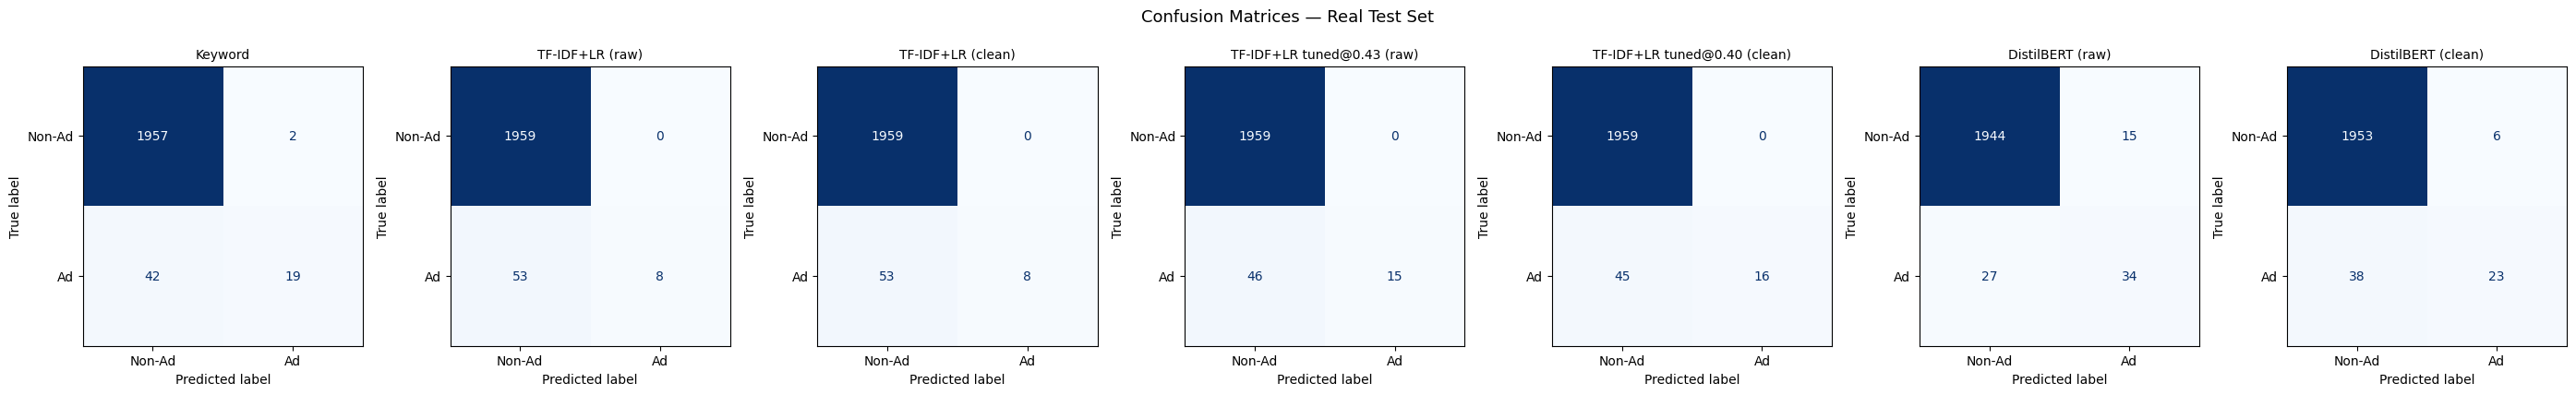

In [41]:
# Confusion matrices for real test set (all 5 model variants)
real_test_results = [r for r in all_results if r["Dataset"] == "Real Test"]
n_models = len(real_test_results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, r in zip(axes, real_test_results):
    cm = np.array([[r["TN"], r["FP"]], [r["FN"], r["TP"]]])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Ad", "Ad"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(r["Model"], fontsize=10)

plt.suptitle("Confusion Matrices — Real Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

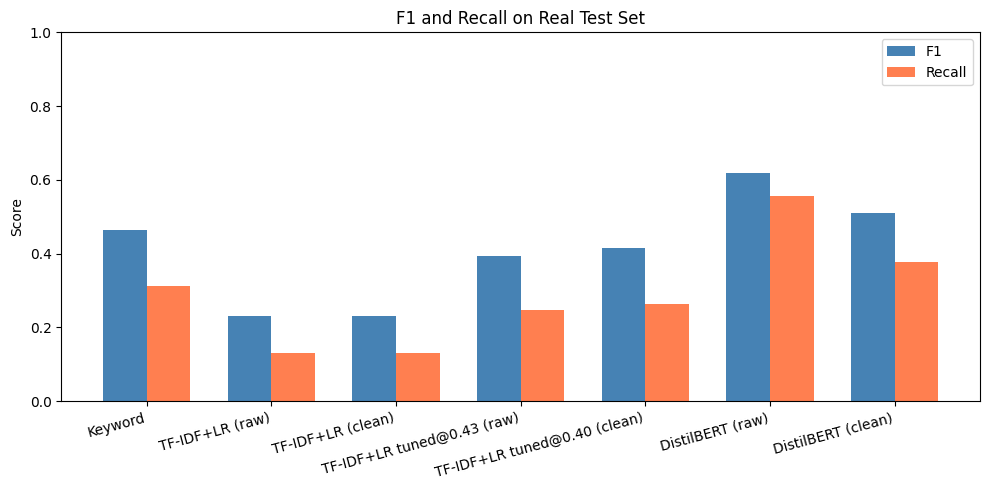

In [42]:
# Bar chart comparing F1 and Recall on real test set
real_models = [r["Model"] for r in real_test_results]
real_f1 = [r["F1"] for r in real_test_results]
real_recall = [r["Recall"] for r in real_test_results]

x = np.arange(len(real_models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, real_f1, width, label="F1", color="steelblue")
ax.bar(x + width/2, real_recall, width, label="Recall", color="coral")
ax.set_ylabel("Score")
ax.set_title("F1 and Recall on Real Test Set")
ax.set_xticks(x)
ax.set_xticklabels(real_models, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Error Analysis

We inspect false negatives (missed ads) and false positives (incorrectly flagged non-ads) across the held-out test videos to understand model behavior.

In [43]:
# Collect all real test predictions into a dict for analysis
model_preds = {
    "Keyword": kw_real_preds,
    "TF-IDF+LR (raw)": lr_raw_real_preds.tolist(),
    "TF-IDF+LR (clean)": lr_clean_real_preds.tolist(),
    f"TF-IDF+LR tuned (raw)": tuned_raw_preds,
    f"TF-IDF+LR tuned (clean)": tuned_clean_preds,
}

# False negatives — which real ads did each model miss?
print("=== False Negatives (Missed Ads) ===\n")
ad_indices = [i for i, l in enumerate(real_labels) if l == 1]
for idx in ad_indices:
    text_preview = real_texts[idx][:120]
    vid = real_test_data[idx]["video_id"]
    missed_by = [name for name, preds in model_preds.items() if preds[idx] == 0]
    caught_by = [name for name, preds in model_preds.items() if preds[idx] == 1]
    print(f"Segment {idx} ({vid}):")
    print(f"  \"{text_preview}...\"")
    print(f"  Caught by: {caught_by if caught_by else 'NONE'}")
    print(f"  Missed by: {missed_by if missed_by else 'NONE'}")
    print()

=== False Negatives (Missed Ads) ===

Segment 187 (H9rF1CSSh-w):
  "a fan on the receiving end of some of those video games, you bring joy to millions of people. It's awesome. Let me ask y..."
  Caught by: ['Keyword', 'TF-IDF+LR (raw)', 'TF-IDF+LR (clean)', 'TF-IDF+LR tuned (raw)', 'TF-IDF+LR tuned (clean)']
  Missed by: NONE

Segment 188 (H9rF1CSSh-w):
  "better help for mental health, Shopify for selling stuff online, code rabbit for AI powered, code review and proplexity ..."
  Caught by: NONE
  Missed by: ['Keyword', 'TF-IDF+LR (raw)', 'TF-IDF+LR (clean)', 'TF-IDF+LR tuned (raw)', 'TF-IDF+LR tuned (clean)']

Segment 386 (H9rF1CSSh-w):
  "you build a big mm all around it quick pause for bathroom break quick 30 second thank you to our sponsors check them out..."
  Caught by: ['Keyword', 'TF-IDF+LR (raw)', 'TF-IDF+LR (clean)', 'TF-IDF+LR tuned (raw)', 'TF-IDF+LR tuned (clean)']
  Missed by: NONE

Segment 387 (H9rF1CSSh-w):
  "less than my friends and now back to my conversation with J

In [44]:
# False positives — sample of non-ad segments incorrectly flagged (best model)
# Use the model with fewest FP on real test as reference
best_model = min(real_test_results, key=lambda r: r["FP"] if r["FP"] > 0 else float("inf"))
best_name = best_model["Model"]
best_preds = model_preds[best_name]

fp_indices = [i for i in range(len(real_labels)) if real_labels[i] == 0 and best_preds[i] == 1]
print(f"=== False Positives for {best_name} ({len(fp_indices)} total) ===\n")
for idx in fp_indices[:10]:  # show up to 10
    text_preview = real_texts[idx][:150]
    vid = real_test_data[idx]["video_id"]
    print(f"Segment {idx} ({vid}):")
    print(f"  \"{text_preview}...\"")
    print()

=== False Positives for Keyword (2 total) ===

Segment 1586 (MiUHjLxm3V0):
  "and never be off by more than five atoms. And this is all happening while parts of the machine whip around at accelerations of over 20 G's. For 30 yea..."

Segment 1757 (Y-W-w8yNiKU):
  "We're coming close to the final few days of the Kickstarter campaign. So this is your last chance to get your hands on the exclusive launch edition. I..."



In [45]:
# Per-video recall breakdown
print("=== Per-Video Recall Breakdown ===\n")
for name, preds in model_preds.items():
    print(f"{name}:")
    for vid in sorted(set(r["video_id"] for r in real_test_data)):
        vid_mask = [i for i, r in enumerate(real_test_data) if r["video_id"] == vid]
        vid_ads = [i for i in vid_mask if real_labels[i] == 1]
        if not vid_ads:
            continue
        caught = sum(1 for i in vid_ads if preds[i] == 1)
        print(f"  {vid}: {caught}/{len(vid_ads)} ads detected")
    print()

=== Per-Video Recall Breakdown ===

Keyword:
  -YNk9_e4pg4: 1/5 ads detected
  -q2n5DkDoMQ: 1/4 ads detected
  1SJiTwbSI58: 2/3 ads detected
  6HVYHNTDOFs: 1/4 ads detected
  7OLVwZeMCfY: 0/1 ads detected
  FRI78tq9Eik: 0/3 ads detected
  H9rF1CSSh-w: 2/4 ads detected
  MiUHjLxm3V0: 1/4 ads detected
  Ol18JoeXlVI: 1/5 ads detected
  P-4pbFcERnk: 1/3 ads detected
  QtxVdC7pBQM: 1/3 ads detected
  Y-W-w8yNiKU: 1/3 ads detected
  YSJY3DvnybE: 2/4 ads detected
  aoag03mSuXQ: 1/3 ads detected
  cMx139eTxoc: 2/4 ads detected
  eXa2ndhmatI: 0/2 ads detected
  iGeXGdYE7UE: 0/3 ads detected
  kBX5WH9b4M4: 2/3 ads detected

TF-IDF+LR (raw):
  -YNk9_e4pg4: 0/5 ads detected
  -q2n5DkDoMQ: 0/4 ads detected
  1SJiTwbSI58: 1/3 ads detected
  6HVYHNTDOFs: 1/4 ads detected
  7OLVwZeMCfY: 0/1 ads detected
  FRI78tq9Eik: 0/3 ads detected
  H9rF1CSSh-w: 2/4 ads detected
  MiUHjLxm3V0: 0/4 ads detected
  Ol18JoeXlVI: 0/5 ads detected
  P-4pbFcERnk: 1/3 ads detected
  QtxVdC7pBQM: 1/3 ads detected
  Y-W-w8y

## 9. Conclusion

### Findings

- **Three approaches** were compared: keyword/regex baseline, TF-IDF + logistic regression, and fine-tuned DistilBERT
- Each learning-based model was trained on both **raw and filler-cleaned** text to measure the effect of preprocessing
- **Mixing real training data** from 8 videos into the synthetic training set helps bridge the synthetic-to-real domain gap — the model sees real Whisper transcription artifacts and genuine ad phrasing during training
- The test set uses 18 held-out videos (split by video to prevent leakage)

### Limitations

- **Synthetic training data**: LLM-generated text is cleaner and more uniform than real Whisper transcriptions; real data helps but the domain gap remains
- **Class imbalance**: Real data is ~97% non-ad, requiring careful threshold tuning
- **CPU training**: Limited to DistilBERT (66M params) rather than larger models
- **Text-only**: No audio features used (mel spectrograms were a stretch goal)

### Future Work

- Collect more real labeled data from SponsorBlock to further increase real training coverage
- Explore audio-based CNN classifier on mel spectrograms for comparison
- Investigate longer context windows to capture segment-level patterns